# Семинар

In [1]:
import cv2
import matplotlib.pyplot as plt
import time
import numpy as np

In [3]:
cam = cv2.VideoCapture(0)
start_time = time.time()

bpm = 120

while(True):
    ret, frame = cam.read()
    curr_time = time.time()

    ind = int((curr_time - start_time) / (60.0 / bpm)) % 4

    if (ind == 0):
        frame += 220

    elif (ind == 1):
        frame[:, :, 2] = 250

    elif (ind == 2):
        frame = 255 - frame

    else:
        s = np.random.randint(30) + 1
        frame[:, s : , 1] = frame[:, : -s, 1]

    cv2.imshow("Flex", frame)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()

# Реализация своих фильтров

#### 1. Синусоидальное переливание цвета по следующему закону:
$$127\cdot\sin(f\cdot k+w\cdot t) + 128$$

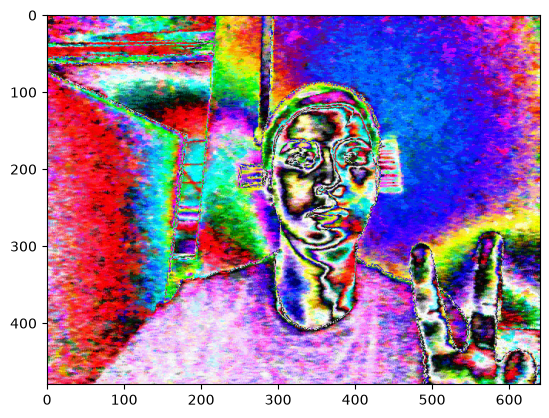

In [ ]:
def sinusoidal_color(start_time):
  ret, frame = cam.read()
  curr_time = time.time()

  t = curr_time - start_time
  frame = (np.sin(frame * 0.2 + 6 * t) * 127 + 128).astype(np.uint8)

  return frame

cam = cv2.VideoCapture(0)
ret, frame = cam.read()
frame = sinusoidal_color(time.time())
plt.imshow(frame)
plt.show()
cam.release()

#### 2. Калейдоскоп.

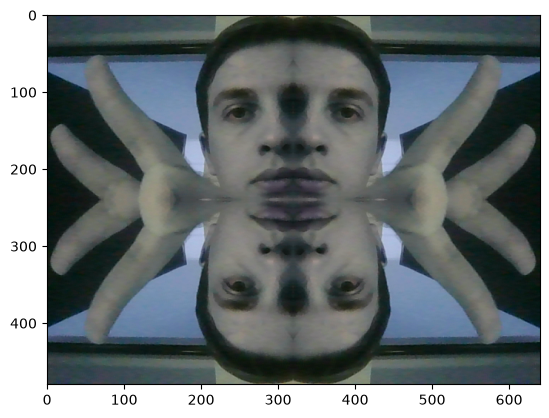

In [63]:
def kaleidoscope():
  ret, frame = cam.read()

  h, w, _ = frame.shape
  top_left = frame[:h//2, :w//2]

  frame[:h//2, w//2:] = cv2.flip(top_left, 1)
  frame[h//2:, :w//2] = cv2.flip(top_left, 0)
  frame[h//2:, w//2:] = cv2.flip(top_left, -1)

  return frame

cam = cv2.VideoCapture(0)
ret, frame = cam.read()
frame = kaleidoscope()
plt.imshow(frame)
plt.show()
cam.release()

#### 3. Дискретизация цветового пространства

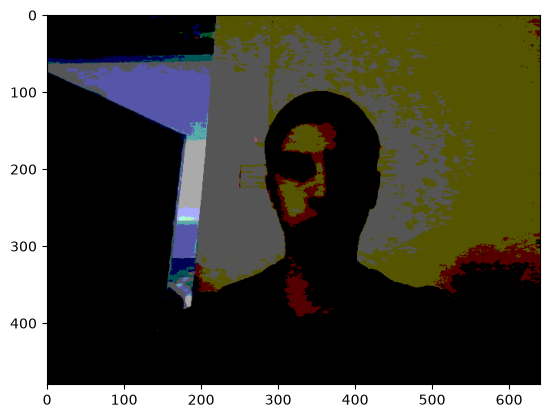

In [75]:
def discretization():
  ret, frame = cam.read()

  levels = 3
  step = 256 // levels
  frame = (frame // step) * step

  return frame

cam = cv2.VideoCapture(0)
ret, frame = cam.read()
frame = discretization()
plt.imshow(frame)
plt.show()
cam.release()

In [ ]:
cam = cv2.VideoCapture(0)
start_time = time.time()

while(True):
  ret, frame = cam.read()
  curr_time = time.time()

  # frame = sinusoidal_color(start_time)
  # frame = kaleidoscope()
  # frame = discretization()

  cv2.imshow("Flex", frame)
  if cv2.waitKey(30) & 0xFF == ord('q'):
    break

cam.release()
cv2.destroyAllWindows()